In [345]:
from collections import namedtuple

Gniazdo = namedtuple('Gniazdo', ['x', 'y'])
Kabelek = namedtuple('Kabelek', ['start', 'koniec'])

In [346]:
nazwa_pliku = 'kab0h.in'

In [347]:
with open(nazwa_pliku, 'r') as plik_we:
    dane = plik_we.readlines()

In [348]:
dane_bez_nowych_linii = []

for linia in dane:
    dane_bez_nowych_linii.append(linia.strip())

In [349]:
liczba_kabelkow = int(dane_bez_nowych_linii[0])

In [350]:
gniazda = dane_bez_nowych_linii[1:]
gniazda = [g.split() for g in gniazda]

In [351]:
gniazda = [Gniazdo(int(g[0]), int(g[1])) for g in gniazda]

In [352]:
print(f"liczba kabelków: {liczba_kabelkow}")
print(f"Gniazda: {gniazda}")

liczba kabelków: 10
Gniazda: [Gniazdo(x=0, y=0), Gniazdo(x=1, y=0), Gniazdo(x=2, y=0), Gniazdo(x=3, y=0), Gniazdo(x=4, y=0), Gniazdo(x=5, y=0), Gniazdo(x=6, y=0), Gniazdo(x=7, y=0), Gniazdo(x=8, y=0), Gniazdo(x=9, y=0), Gniazdo(x=10, y=0), Gniazdo(x=11, y=0), Gniazdo(x=12, y=0), Gniazdo(x=13, y=0), Gniazdo(x=14, y=0), Gniazdo(x=15, y=0), Gniazdo(x=16, y=0), Gniazdo(x=17, y=0), Gniazdo(x=18, y=0), Gniazdo(x=19, y=0)]


In [353]:
# przypadek najprostszy
if  liczba_kabelkow == 1:
    print(gniazda)

In [354]:
kombinacje = []
for gniazdo_1 in gniazda:
    for gniazdo_2 in gniazda[1:]:
        if gniazdo_2 != gniazdo_1 and not (gniazdo_2, gniazdo_1) in kombinacje:
            kombinacje.append(Kabelek(gniazdo_1, gniazdo_2))

In [355]:
def czy_sie_przecinaja(kabelek_1: Kabelek, kabelek_2: Kabelek):
    if kabelek_1.start in kabelek_2 or kabelek_1.koniec in kabelek_2:
        return True
    
    def pdrwz(a, b, c):
        return (c.y-a.y) * (b.x-a.x) > (b.y-a.y) * (c.x-a.x)
    
    def przecinaja_sie(a, b, c, d):
        return pdrwz(a, c, d) != pdrwz(b, c, d) and pdrwz(a, b, c) != pdrwz(a, b, d)
    
    return przecinaja_sie(kabelek_1.start, kabelek_1.koniec, kabelek_2.start, kabelek_2.koniec)

In [356]:

k1 = Kabelek(start=Gniazdo(x=16, y=50), koniec=Gniazdo(x=59, y=24))
k2 = Kabelek(start=Gniazdo(x=34, y=37), koniec=Gniazdo(x=16, y=53))

czy_sie_przecinaja(k1, k2)

True

In [357]:
def czy_sie_przecina_z_innymi(kabelek, kabelki):
    for k in kabelki:
        if czy_sie_przecinaja(kabelek, k):
            return True
    return False


In [358]:
k_test = Kabelek(start=Gniazdo(x=34, y=37), koniec=Gniazdo(x=16, y=53))
k_inne = [Kabelek(start=Gniazdo(x=5, y=59), koniec=Gniazdo(x=19, y=70)), Kabelek(start=Gniazdo(x=16, y=50), koniec=Gniazdo(x=59, y=24))]

czy_sie_przecina_z_innymi(k_test, k_inne)

True

In [359]:
def znajdz_kabelki_bez_przecinania(kombinacje):

    for i in range(len(kombinacje)):
        kabelki_bez_przecinania = []
        kabelki_bez_przecinania.append(kombinacje[i])
        for j in range(i + 1, len(kombinacje)):
            kabelek = kombinacje[j]
            if not czy_sie_przecina_z_innymi(kabelek, kabelki_bez_przecinania):
                kabelki_bez_przecinania.append(kabelek)
            if len(kabelki_bez_przecinania) == liczba_kabelkow:
                return kabelki_bez_przecinania    
            

wynik = znajdz_kabelki_bez_przecinania(kombinacje)      

print(wynik)

[Kabelek(start=Gniazdo(x=0, y=0), koniec=Gniazdo(x=1, y=0)), Kabelek(start=Gniazdo(x=2, y=0), koniec=Gniazdo(x=3, y=0)), Kabelek(start=Gniazdo(x=4, y=0), koniec=Gniazdo(x=5, y=0)), Kabelek(start=Gniazdo(x=6, y=0), koniec=Gniazdo(x=7, y=0)), Kabelek(start=Gniazdo(x=8, y=0), koniec=Gniazdo(x=9, y=0)), Kabelek(start=Gniazdo(x=10, y=0), koniec=Gniazdo(x=11, y=0)), Kabelek(start=Gniazdo(x=12, y=0), koniec=Gniazdo(x=13, y=0)), Kabelek(start=Gniazdo(x=14, y=0), koniec=Gniazdo(x=15, y=0)), Kabelek(start=Gniazdo(x=16, y=0), koniec=Gniazdo(x=17, y=0)), Kabelek(start=Gniazdo(x=18, y=0), koniec=Gniazdo(x=19, y=0))]


In [360]:
for k in wynik:
    print(f"{k.start.x} {k.start.y} {k.koniec.x} {k.koniec.y}")

0 0 1 0
2 0 3 0
4 0 5 0
6 0 7 0
8 0 9 0
10 0 11 0
12 0 13 0
14 0 15 0
16 0 17 0
18 0 19 0


In [361]:
wynik_ok = True

for i in range(len(wynik)):
    k1 = wynik[i]
    for j in range(i + 1, len(wynik)):
        k2 = wynik[j]
        if czy_sie_przecinaja(k1, k2):
            wynik_ok = False
            print(f"Przecinające się kabelki: {k1} - {k2}")
            break

wynik_ok

True

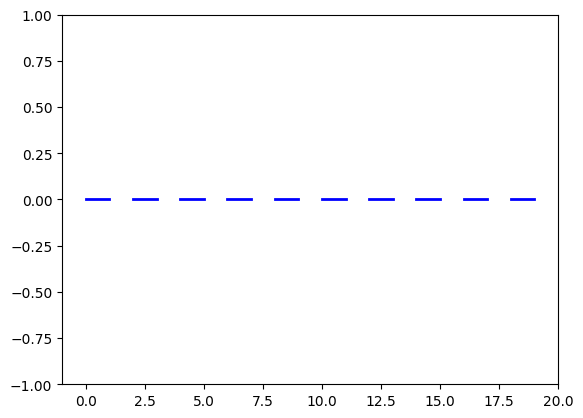

In [362]:
%matplotlib inline
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Create a figure and an axes
fig, ax = plt.subplots()

xlim_min = 100
xlim_max = -100
ylim_min, ylim_max = xlim_min, xlim_max

for k in wynik:
    # Create a Line2D instance
    x_values = list(zip(k.start, k.koniec))[0]
    xlim_min = min(xlim_min, min(x_values))
    xlim_max = max(xlim_max, max(x_values))

    y_values = list(zip(k.start, k.koniec))[1]
    ylim_min = min(ylim_min, min(y_values))
    ylim_max = max(ylim_max, max(y_values))

    line = Line2D(x_values, y_values, linewidth=2, linestyle='-', color='blue')
    # Add the line to the axes
    ax.add_line(line)

# # Set the limits of the plot
ax.set_xlim(xlim_min - 1, xlim_max + 1)
ax.set_ylim(ylim_min - 1 , ylim_max + 1)

# Display the plot
plt.show()